<a href="https://colab.research.google.com/github/janhavipatkar854/CSL701-CS42-Machine-Learning-Lab/blob/main/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Janhavi n Patkar Roll No : Cs 42 Batch : Cs 3

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [2]:
# Task 1: Environment Setup and Dataset Acquisition

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Define column names
column_names = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Load the dataset
df = pd.read_csv('/content/diabetes.csv', names=column_names)

# Display first five records
print("First five records of the dataset:")
display(df.head())

# Display dataset shape
print("\nDataset shape:")
print(df.shape)

# Display data types
print("\nData types of all features:")
print(df.dtypes)

# Display descriptive statistics
print("\nDescriptive statistics of the numeric features:")
display(df.describe())

First five records of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,169.5,33.6,0.627,50,1
2,1,85,66,29,102.5,26.6,0.351,31,0
3,8,183,64,32,169.5,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0



Dataset shape:
(769, 9)

Data types of all features:
Pregnancies                 object
Glucose                     object
BloodPressure               object
SkinThickness               object
Insulin                     object
BMI                         object
DiabetesPedigreeFunction    object
Age                         object
Outcome                     object
dtype: object

Descriptive statistics of the numeric features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769,769,769,769,769,769,769,769,769
unique,18,136,48,51,188,248,518,53,3
top,1,100,70,27,102.5,30.1,0.258,22,0
freq,135,17,76,162,236,18,6,72,500


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Absolute count of Outcome classes:
Non-Diabetic (0): 500
Diabetic (1): 268

Percentage of Outcome classes:
Non-Diabetic (0): 65.02 %
Diabetic (1): 34.85 %


/tmp/ipykernel_1988/4086265688.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Non-Diabetic (0):", class_counts[0])
/tmp/ipykernel_1988/4086265688.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Diabetic (1):", class_counts[1])
/tmp/ipykernel_1988/4086265688.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Non-Diabetic (0):", round(class_percentages[0], 2), "%")
/tmp/ipykernel_1988/4086265688.py:14:

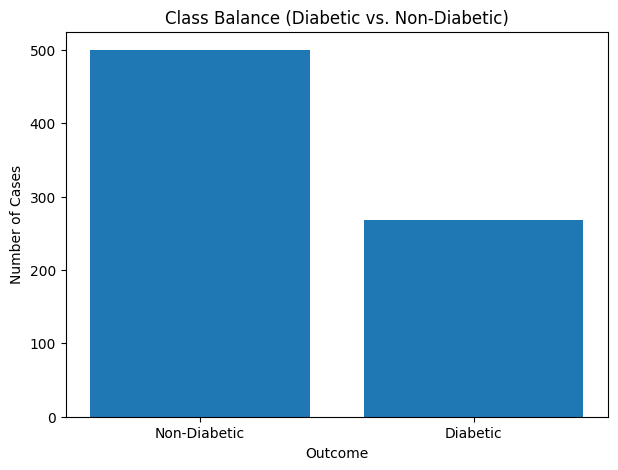

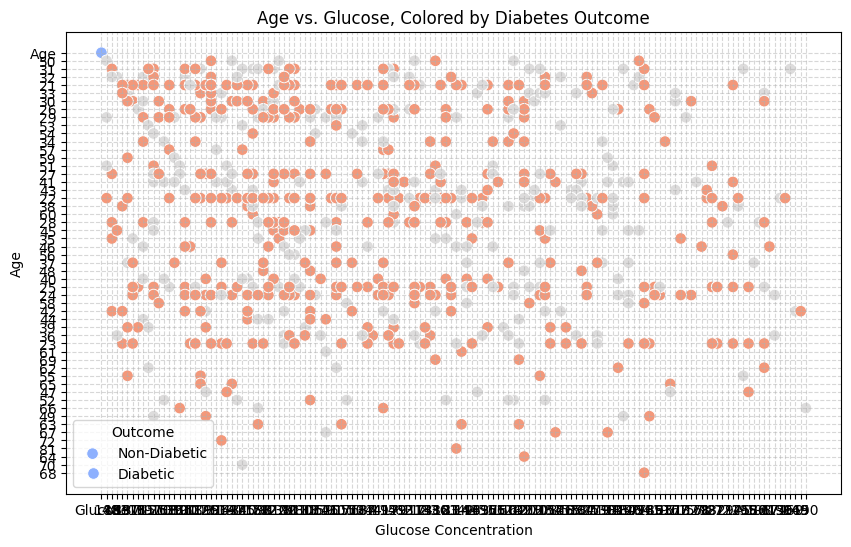

In [3]:
# Task 2: Exploratory Data Analysis (EDA)

# 1. Calculate absolute count and percentage of each Outcome class

class_counts = df['Outcome'].value_counts().sort_index()
class_percentages = df['Outcome'].value_counts(normalize=True).sort_index() * 100

print("Absolute count of Outcome classes:")
print("Non-Diabetic (0):", class_counts[0])
print("Diabetic (1):", class_counts[1])

print("\nPercentage of Outcome classes:")
print("Non-Diabetic (0):", round(class_percentages[0], 2), "%")
print("Diabetic (1):", round(class_percentages[1], 2), "%")


# Plot class balance
plt.figure(figsize=(7, 5))

plt.bar(
    ['Non-Diabetic', 'Diabetic'],
    [class_counts[0], class_counts[1]]
)

plt.title('Class Balance (Diabetic vs. Non-Diabetic)')
plt.xlabel('Outcome')
plt.ylabel('Number of Cases')

plt.show()


# 2. Scatter plot of Age against Glucose,
#    color-coded according to Outcome

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Glucose',
    y='Age',
    hue='Outcome',
    palette='coolwarm',
    s=70
)

plt.title('Age vs. Glucose, Colored by Diabetes Outcome')
plt.xlabel('Glucose Concentration')
plt.ylabel('Age')

plt.legend(
    title='Outcome',
    labels=['Non-Diabetic', 'Diabetic']
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [5]:
# Task 3: Preprocessing and Handling Missing Values

# Features where 0 is physically impossible
invalid_zero_features = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Drop the header row if it was mistakenly read as data
if df.iloc[0]['Outcome'] == 'Outcome':
    df = df.iloc[1:].reset_index(drop=True)

# Convert columns to numeric types so we can compute medians
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Display number of zero values before replacement
print("Number of zero values before replacement:")
for feature in invalid_zero_features:
    print(feature, ":", (df[feature] == 0).sum())

# Replace invalid zero values with NaN
df[invalid_zero_features] = df[invalid_zero_features].replace(0, np.nan)

# Display missing values after replacement
print("\nMissing values after replacing zeros with NaN:")
print(df[invalid_zero_features].isnull().sum())

# Impute missing values using the median of each feature
for feature in invalid_zero_features:
    df[feature] = df[feature].fillna(df[feature].median())

# Check that no missing values remain
print("\nMissing values after median imputation:")
print(df.isnull().sum())

# Display first five records after preprocessing
print("\nFirst five records after preprocessing:")
display(df.head())

Number of zero values before replacement:
Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0

Missing values after replacing zeros with NaN:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

First five records after preprocessing:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [6]:
# Task 4: Stratified Train-Test Splitting

# Separate features (X) and target (y)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split the dataset into 80% training and 20% testing
# stratify=y preserves the class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the datasets
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

# Check class distribution in the original, training and test datasets
print("\nOriginal class distribution:")
print(y.value_counts(normalize=True).sort_index())

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training data shape: (614, 8)
Test data shape: (154, 8)

Original class distribution:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Training class distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Test class distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [7]:
# Task 5: Custom Bootstrap Sampling Function

# Function to generate a bootstrap sample
def get_bootstrap_sample(X, y):
    # Number of samples in the training dataset
    N = len(X)

    # Randomly select indices with replacement
    bootstrap_indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[bootstrap_indices].copy()
    y_bootstrap = y.iloc[bootstrap_indices].copy()

    return X_bootstrap, y_bootstrap, bootstrap_indices


# Generate one bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

# Display sizes
print("Original training set size:", len(X_train))
print("Bootstrap sample size:", len(X_bootstrap))
print("Bootstrap target size:", len(y_bootstrap))

# Check for duplicated indices
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicated_indices = unique_indices[counts > 1]

print("\nNumber of unique samples selected:",
      len(unique_indices))

print("Number of duplicated samples:",
      len(duplicated_indices))

if len(duplicated_indices) > 0:
    print("Some original row indices are duplicated:")
    print(duplicated_indices[:10])
else:
    print("No duplicated indices found in this sample.")


# Find Out-of-Bag (OOB) indices
original_indices = np.arange(len(X_train))

oob_indices = np.setdiff1d(
    original_indices,
    unique_indices
)

print("\nNumber of Out-of-Bag (OOB) samples:",
      len(oob_indices))

if len(oob_indices) > 0:
    print("Some original row indices are omitted (OOB):")
    print(oob_indices[:10])
else:
    print("No OOB samples found in this sample.")


# Verify that bootstrap sample has the same size as training data
print("\nVerification:")
print("|X_bootstrap| =", len(X_bootstrap))
print("|y_bootstrap| =", len(y_bootstrap))
print("|X_train|     =", len(X_train))

Original training set size: 614
Bootstrap sample size: 614
Bootstrap target size: 614

Number of unique samples selected: 385
Number of duplicated samples: 164
Some original row indices are duplicated:
[ 0  2 13 17 19 20 22 39 42 43]

Number of Out-of-Bag (OOB) samples: 229
Some original row indices are omitted (OOB):
[ 4  5  6  7 10 12 14 15 16 18]

Verification:
|X_bootstrap| = 614
|y_bootstrap| = 614
|X_train|     = 614


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [8]:
# Task 6: Growing the Ensemble of Base Classifiers

# Number of bootstrap iterations / base classifiers
B = 50

# Initialize an empty list to store the trained models
ensemble = []

# Train B decision trees
for b in range(B):

    # Generate a bootstrap sample
    X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the model on the bootstrap sample
    model.fit(X_bootstrap, y_bootstrap)

    # Add the trained model to the ensemble
    ensemble.append(model)

# Verify the number of trained models
print("Number of Decision Trees in the ensemble:", len(ensemble))
print("Expected number of Decision Trees:", B)

Number of Decision Trees in the ensemble: 50
Expected number of Decision Trees: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [9]:
# Task 7: Implementing Aggregation (Majority Voting) from Scratch

# Custom Bagging prediction function
def custom_bagging_predict(ensemble, X_test):

    # Store predictions from all decision trees
    all_predictions = []

    # Get predictions from each tree
    for model in ensemble:
        predictions = model.predict(X_test)
        all_predictions.append(predictions)

    # Convert predictions into a NumPy array
    # Shape: (number of trees, number of test samples)
    all_predictions = np.array(all_predictions)

    # Store final majority-voted predictions
    final_predictions = []

    # Perform majority voting for each test sample
    for i in range(all_predictions.shape[1]):

        # Get votes from all trees for the current sample
        votes = all_predictions[:, i]

        # Count votes for each class
        counts = np.bincount(votes.astype(int))

        # Select the class with the highest number of votes
        majority_class = np.argmax(counts)

        final_predictions.append(majority_class)

    # Return final predictions as a NumPy array
    return np.array(final_predictions)


# Generate Bagging predictions on the test data
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

# Display the first 20 predictions
print("First 20 Bagging predictions:")
print(y_pred_bagging[:20])

# Verify that predictions contain only 0 and 1
print("\nUnique predicted classes:")
print(np.unique(y_pred_bagging))

# Verify number of predictions
print("\nNumber of test samples:", len(X_test))
print("Number of Bagging predictions:", len(y_pred_bagging))

First 20 Bagging predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0]

Unique predicted classes:
[0 1]

Number of test samples: 154
Number of Bagging predictions: 154


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

===== PERFORMANCE COMPARISON =====

Single Decision Tree:
Accuracy : 0.8117
Precision: 0.7451
Recall   : 0.7037
F1-Score : 0.7238

Bagging Ensemble:
Accuracy : 0.8831
Precision: 0.8333
Recall   : 0.8333
F1-Score : 0.8333

Confusion Matrix - Single Decision Tree:
[[87 13]
 [16 38]]

Confusion Matrix - Bagging Ensemble:
[[91  9]
 [ 9 45]]


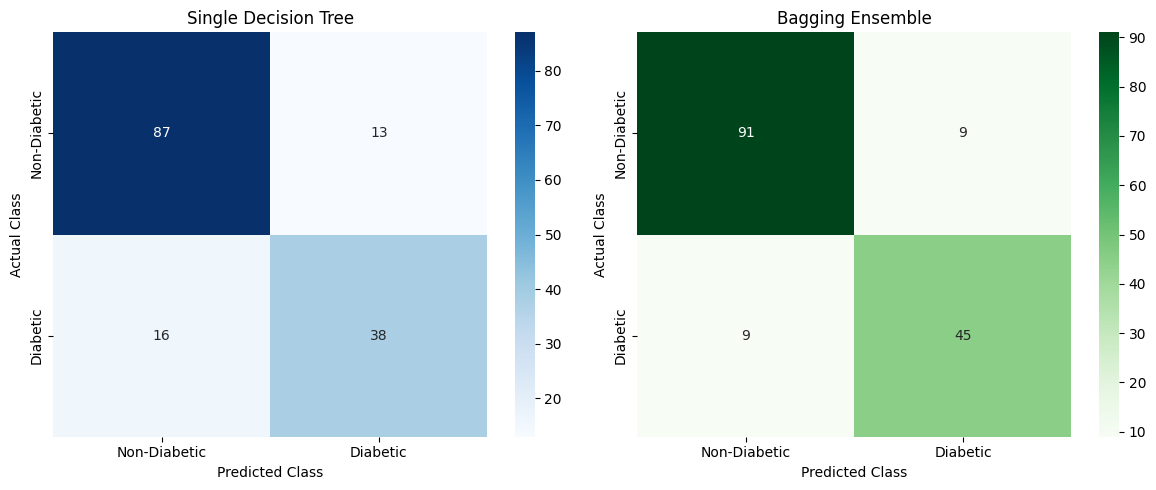

In [10]:
# Task 8: Single Classifier vs. Bagging Performance Comparison

# 1. Train a standalone fully grown Decision Tree
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)

# 2. Make predictions using the single tree
y_pred_single = single_tree.predict(X_test)

# y_pred_bagging was already created in Task 7


# 3. Calculate evaluation metrics

# Single Decision Tree metrics
single_accuracy = accuracy_score(y_test, y_pred_single)
single_precision = precision_score(y_test, y_pred_single)
single_recall = recall_score(y_test, y_pred_single)
single_f1 = f1_score(y_test, y_pred_single)

# Bagging metrics
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(y_test, y_pred_bagging)
bagging_recall = recall_score(y_test, y_pred_bagging)
bagging_f1 = f1_score(y_test, y_pred_bagging)


# 4. Print performance comparison

print("===== PERFORMANCE COMPARISON =====")

print("\nSingle Decision Tree:")
print("Accuracy :", round(single_accuracy, 4))
print("Precision:", round(single_precision, 4))
print("Recall   :", round(single_recall, 4))
print("F1-Score :", round(single_f1, 4))

print("\nBagging Ensemble:")
print("Accuracy :", round(bagging_accuracy, 4))
print("Precision:", round(bagging_precision, 4))
print("Recall   :", round(bagging_recall, 4))
print("F1-Score :", round(bagging_f1, 4))


# 5. Construct confusion matrices

cm_single = confusion_matrix(y_test, y_pred_single)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

print("\nConfusion Matrix - Single Decision Tree:")
print(cm_single)

print("\nConfusion Matrix - Bagging Ensemble:")
print(cm_bagging)


# 6. Visualize both confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_single,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic'],
    ax=axes[0]
)

axes[0].set_title('Single Decision Tree')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('Actual Class')


sns.heatmap(
    cm_bagging,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic'],
    ax=axes[1]
)

axes[1].set_title('Bagging Ensemble')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('Actual Class')

plt.tight_layout()
plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

===== ROC-AUC COMPARISON =====
Single Decision Tree AUC: 0.7869
Bagging Ensemble AUC: 0.9513


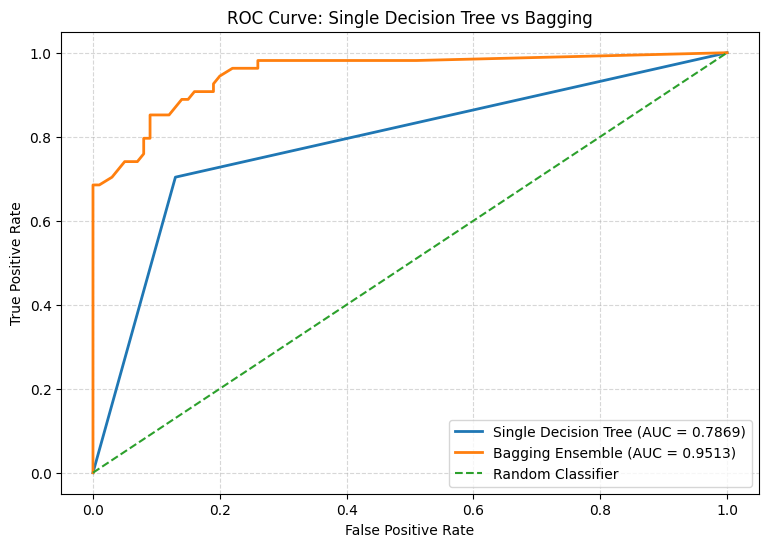

In [11]:
# Task 9: ROC-AUC Analysis and Curve Visualization

# 1. Get probability estimates from the single Decision Tree
single_tree_probabilities = single_tree.predict_proba(X_test)[:, 1]


# 2. Get probability estimates from all trees in the Bagging ensemble

all_tree_probabilities = []

for model in ensemble:
    probabilities = model.predict_proba(X_test)[:, 1]
    all_tree_probabilities.append(probabilities)

# Convert to NumPy array
all_tree_probabilities = np.array(all_tree_probabilities)


# 3. Average probabilities across all 50 trees
bagging_probabilities = np.mean(
    all_tree_probabilities,
    axis=0
)


# 4. Calculate ROC curve for Single Decision Tree
fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    single_tree_probabilities
)

# Calculate AUC
auc_single = roc_auc_score(
    y_test,
    single_tree_probabilities
)


# 5. Calculate ROC curve for Bagging
fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    bagging_probabilities
)

# Calculate AUC
auc_bagging = roc_auc_score(
    y_test,
    bagging_probabilities
)


# 6. Print AUC values

print("===== ROC-AUC COMPARISON =====")

print("Single Decision Tree AUC:",
      round(auc_single, 4))

print("Bagging Ensemble AUC:",
      round(auc_bagging, 4))


# 7. Plot both ROC curves

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f'Single Decision Tree (AUC = {auc_single:.4f})',
    linewidth=2
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f'Bagging Ensemble (AUC = {auc_bagging:.4f})',
    linewidth=2
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Single Decision Tree vs Bagging')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

===== CUSTOM BAGGING vs SCIKIT-LEARN BAGGING =====

Custom Bagging Implementation
--------------------------------
Accuracy: 0.8831
Confusion Matrix:
[[91  9]
 [ 9 45]]

Scikit-Learn BaggingClassifier
--------------------------------
Accuracy: 0.8831
Confusion Matrix:
[[91  9]
 [ 9 45]]

===== ACCURACY COMPARISON =====
Custom Bagging Accuracy: 0.8831
Scikit-Learn Bagging Accuracy: 0.8831
Difference: 0.0


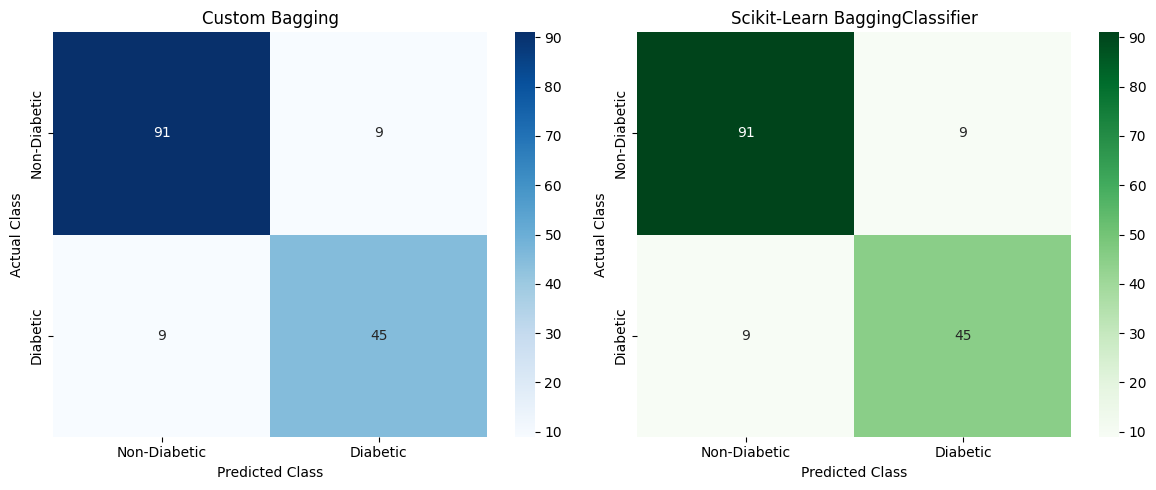

In [12]:
# Task 10: Validation against Scikit-Learn's BaggingClassifier

from sklearn.ensemble import BaggingClassifier

# 1. Create the base Decision Tree
base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# 2. Create Scikit-Learn's Bagging Classifier
sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)

# 3. Train the Bagging Classifier
sklearn_bagging.fit(X_train, y_train)

# 4. Predict on the test data
y_pred_sklearn = sklearn_bagging.predict(X_test)

# 5. Calculate accuracy
sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)

# Accuracy of our custom Bagging implementation
custom_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)

# 6. Calculate confusion matrices
cm_custom = confusion_matrix(
    y_test,
    y_pred_bagging
)

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)


# 7. Print comparison

print("===== CUSTOM BAGGING vs SCIKIT-LEARN BAGGING =====")

print("\nCustom Bagging Implementation")
print("--------------------------------")
print("Accuracy:", round(custom_accuracy, 4))
print("Confusion Matrix:")
print(cm_custom)

print("\nScikit-Learn BaggingClassifier")
print("--------------------------------")
print("Accuracy:", round(sklearn_accuracy, 4))
print("Confusion Matrix:")
print(cm_sklearn)


# 8. Display accuracy comparison

print("\n===== ACCURACY COMPARISON =====")
print("Custom Bagging Accuracy:",
      round(custom_accuracy, 4))

print("Scikit-Learn Bagging Accuracy:",
      round(sklearn_accuracy, 4))

print("Difference:",
      round(abs(custom_accuracy - sklearn_accuracy), 4))


# 9. Visualize both confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_custom,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic'],
    ax=axes[0]
)

axes[0].set_title('Custom Bagging')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('Actual Class')


sns.heatmap(
    cm_sklearn,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic'],
    ax=axes[1]
)

axes[1].set_title('Scikit-Learn BaggingClassifier')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('Actual Class')

plt.tight_layout()
plt.show()

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?